## Checks on the data for NaN and such 

In [ ]:
import vitaldb
vitaldb.login("username", "password")

True

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
os.chdir('C:/GU/Thesis/code')

from tqdm import tqdm

In [5]:
print(os.getcwd())

data = pd.read_csv(os.path.join("cases_data.csv"))
case_ids = data['caseid'].tolist()

preprocessed_path = os.path.join("eeg")

C:\GU\Thesis\code


In [40]:
for case in case_ids:
    n_nans = 0
    n_below_10 = 0
    case_path = os.path.join(preprocessed_path, f"case_{case}.pt")
    case_data = torch.load(case_path)

    features = case_data['features'].numpy()
    bis      = case_data['bis'].numpy()

    n_nans = np.sum(np.isnan(bis))
    n_below_10 = (bis < 10).sum()

    if n_nans > 0 or n_below_10 > 0:
        print(f"Case {case} has {n_nans} NaNs and {n_below_10} values below 10 in BIS.")

Number of BIS values equal to 0: 0


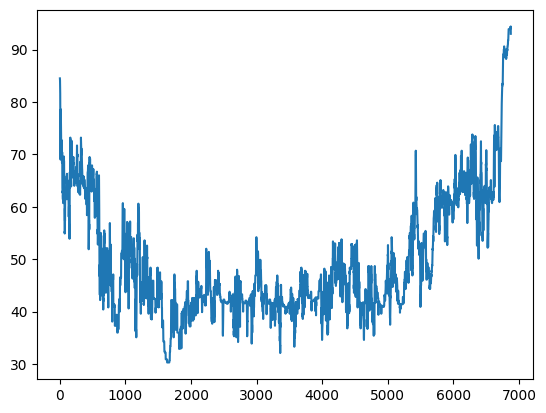

In [6]:
case_path = os.path.join(preprocessed_path, f"case_2460.pt")
sample = torch.load(case_path)

bis = sample['bis'].numpy()

n_bis_zero = np.sum(bis == 0)
print(f"Number of BIS values equal to 0: {n_bis_zero}")

plt.plot(bis)

Significant issues with BIS values of 0 that significantly impact our predition abilities. 

## Visualization for data rejection and updated BIS coverage

In [15]:
os.getcwd()

'C:\\GU\\Thesis\\code'

In [27]:
valid_eeg_cases = pd.read_csv(os.path.join('valid_sqi_ranges.csv'))
valid_caseid = valid_eeg_cases['caseid']

valid_eeg_cases.index = valid_caseid

# ── Config ────────────────────────────────────────────────────────────────────
TRACKS       = ['BIS/BIS', 'BIS/SQI', 'BIS/EMG']
VITAL_TRACKS = ['Solar8000/ART_MBP', 'Solar8000/NIBP_MBP', 'Solar8000/HR', 'Solar8000/PLETH_SPO2', 'Solar8000/ETCO2']
N_SAMPLE     = 100
INTERVAL     = 1  # 1s resolution for numeric tracks
INTERVAL_VITAL = 2  # 2s resolution for vital tracks (to speed up loading)
RANDOM_SEED  = 42

# ── Sample cases ──────────────────────────────────────────────────────────────
rng          = np.random.default_rng(RANDOM_SEED)
sample_ids   = rng.choice(valid_caseid, size=N_SAMPLE, replace=False)

# ── Per-case statistics ───────────────────────────────────────────────────────
results = []

for caseid in tqdm(sample_ids):
    try:
        data = vitaldb.load_case(caseid, TRACKS, interval=INTERVAL)
        data_vital = vitaldb.load_case(caseid, VITAL_TRACKS, interval=INTERVAL_VITAL)

        start = valid_eeg_cases.at[caseid, 'sqi_start']
        end = valid_eeg_cases.at[caseid, 'sqi_end']

        if data is None or len(data) == 0:
            continue

        bis  = data[start:end, 0]
        sqi  = data[start:end, 1]
        emg  = data[start:end, 2]

        art_invasive = data_vital[start//2:end//2, 0]
        art_nibp     = data_vital[start//2:end//2, 1]
        cov_inv  = np.mean(~np.isnan(art_invasive))
        cov_nibp = np.mean(~np.isnan(art_nibp))

        hr = data_vital[start//2:end//2, 2]
        hr_valid = ~np.isnan(hr)

        spo2 = data_vital[start//2:end//2, 3]
        spo2_valid = ~np.isnan(spo2)

        etco2 = data_vital[start//2:end//2, 4]
        etco2_valid = ~np.isnan(etco2)

        # Valid mask: timesteps where BIS is not NaN
        bis[bis <= 10] = np.nan 
        valid = ~np.isnan(bis)
        n_total   = len(bis)
        n_valid   = valid.sum()

        if n_valid == 0:
            continue

        results.append({
            'caseid'        : caseid,
            'duration_min'  : n_total / 60,
            'bis_coverage'  : n_valid / n_total,          # fraction of valid BIS
            'bis_mean'      : np.nanmean(bis),
            'bis_std'       : np.nanstd(bis),
            'bis_range'     : np.nanmax(bis) - np.nanmin(bis),
            'bis_max'       : np.nanmax(bis),
            'bis_min'       : np.nanmin(bis),
            'sqi_mean'      : np.nanmean(sqi),
            'sqi_min'       : np.nanmin(sqi),
            'sqi_p10'       : np.nanpercentile(sqi, 10),  # 10th pct more robust than min
            'emg_mean'      : np.nanmean(emg),
            'emg_p90'       : np.nanpercentile(emg, 90),  # high EMG periods
            'art_coverage'  : np.max([cov_inv, cov_nibp]),  # coverage of either invasive or NIBP
            'hr_coverage'   : np.nanmean(hr_valid),
            'spo2_coverage' : np.nanmean(spo2_valid),
            'etco2_coverage' : np.nanmean(etco2_valid),
        })

    except Exception as e:
        print(f"Case {caseid} failed: {e}")
        continue

import pandas as pd
df = pd.DataFrame(results)
#print(df.describe())

100%|██████████| 100/100 [05:46<00:00,  3.46s/it]


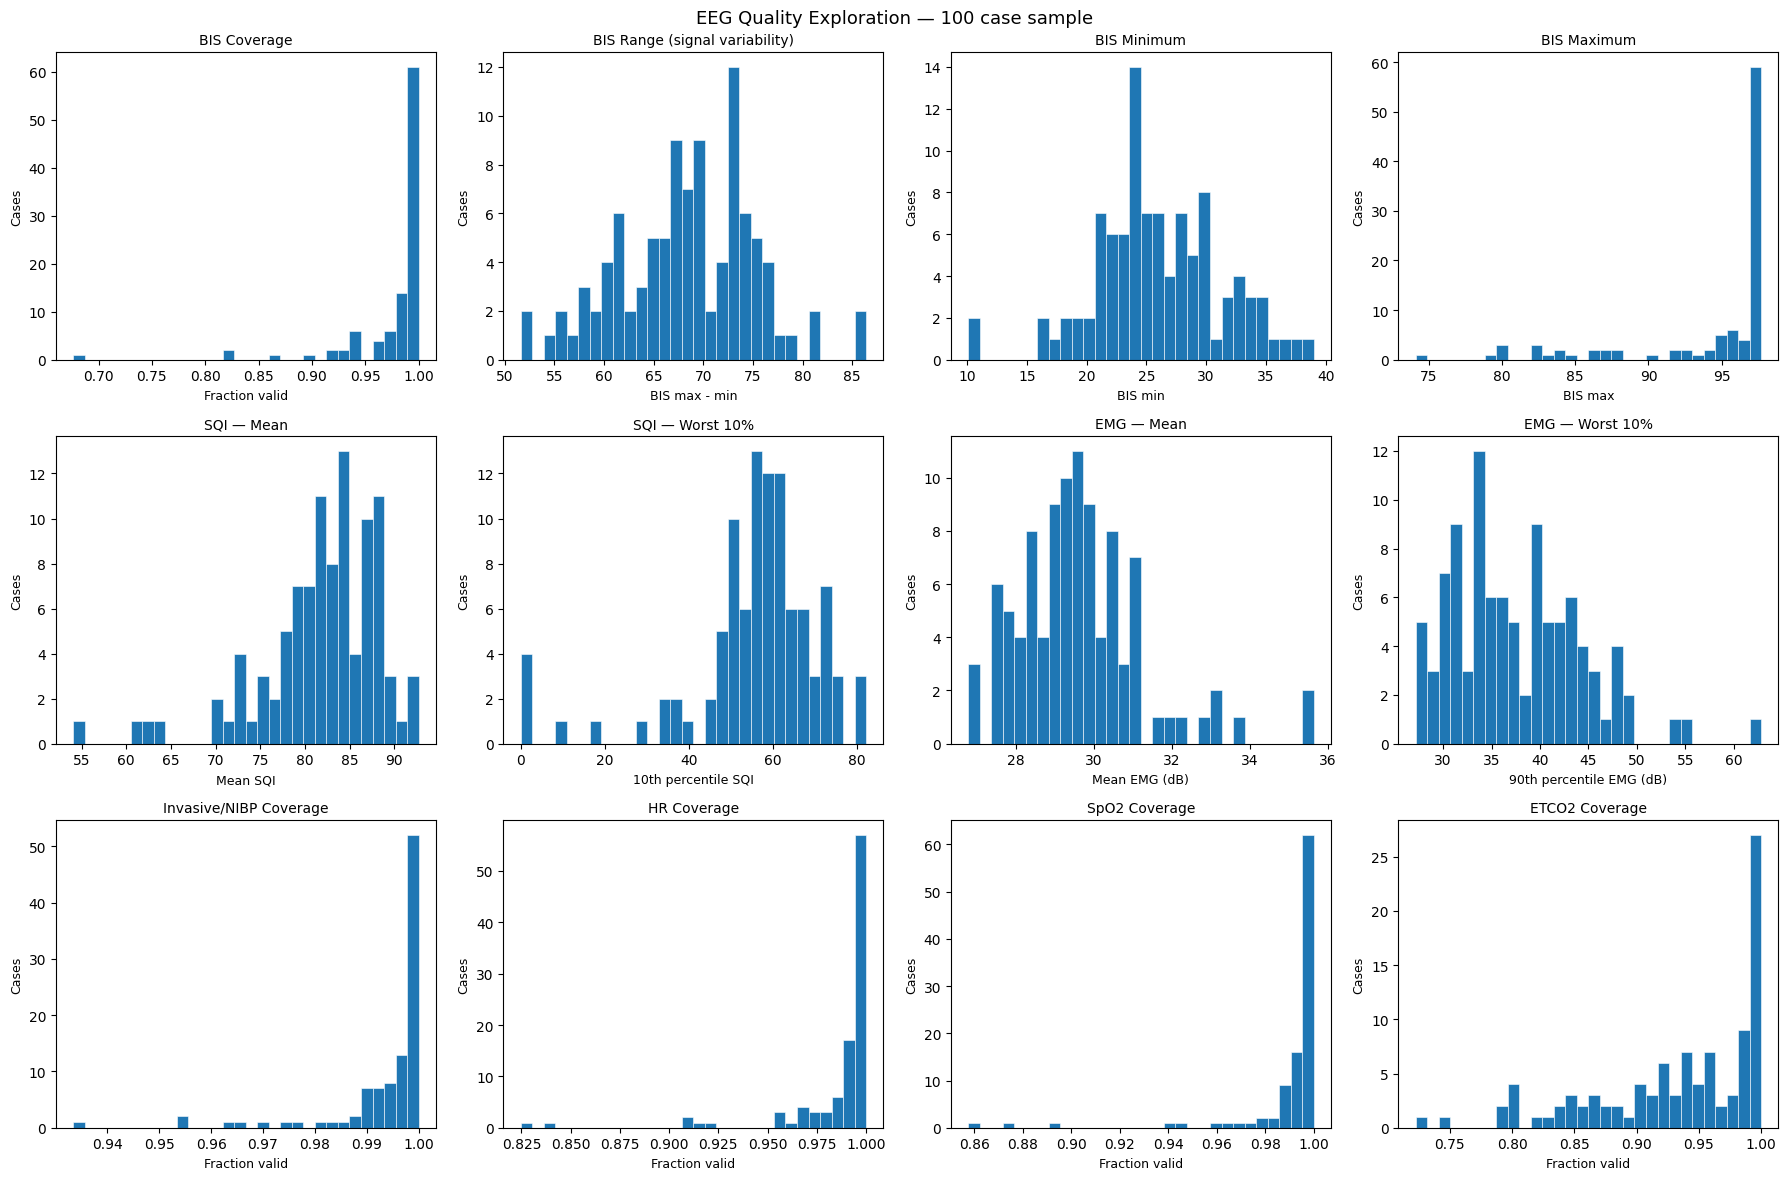

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('EEG Quality Exploration — 100 case sample', fontsize=13)

plots = [
    #('duration_min',  'Duration (min)',         'Case Duration'),
    ('bis_coverage',  'Fraction valid',          'BIS Coverage'),
    ('bis_range',     'BIS max - min',           'BIS Range (signal variability)'),
    ('bis_min',      'BIS min',                'BIS Minimum'),
    ('bis_max',      'BIS max',                'BIS Maximum'),
    ('sqi_mean',      'Mean SQI',                'SQI — Mean'),
    ('sqi_p10',       '10th percentile SQI',     'SQI — Worst 10%'),
    ('emg_mean',      'Mean EMG (dB)',            'EMG — Mean'),
    ('emg_p90',       '90th percentile EMG (dB)','EMG — Worst 10%'),
    ('art_coverage',  'Fraction valid',          'Invasive/NIBP Coverage'),
    ('hr_coverage',   'Fraction valid',          'HR Coverage'),
    ('spo2_coverage', 'Fraction valid',          'SpO2 Coverage'),
    ('etco2_coverage', 'Fraction valid',         'ETCO2 Coverage'),
]

for ax, (col, xlabel, title) in zip(axes.flat, plots):
    ax.hist(df[col].dropna(), bins=30, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Cases', fontsize=9)

plt.tight_layout()
plt.savefig('eeg_quality_exploration.png', dpi=150)
plt.show()

In [18]:
valid_eeg_cases = pd.read_csv(os.path.join('valid_sqi_ranges.csv'))
valid_caseid = valid_eeg_cases['caseid']

valid_eeg_cases.index = valid_caseid

# ── Config ────────────────────────────────────────────────────────────────────
TRACKS       = ['BIS/BIS', 'BIS/SQI', 'BIS/EMG']
N_SAMPLE     = 100
INTERVAL     = 1  # 1s resolution for numeric tracks
RANDOM_SEED  = 42

# ── Sample cases ──────────────────────────────────────────────────────────────
rng          = np.random.default_rng(RANDOM_SEED)
sample_ids   = rng.choice(valid_caseid, size=N_SAMPLE, replace=False)

# ── Per-case statistics ───────────────────────────────────────────────────────
results = []

for caseid in tqdm(sample_ids):
    try:
        data = vitaldb.load_case(caseid, TRACKS, interval=INTERVAL)
        start = valid_eeg_cases.at[caseid, 'sqi_start']
        end = valid_eeg_cases.at[caseid, 'sqi_end']

        if data is None or len(data) == 0:
            continue

        bis  = data[start:end, 0]
        sqi  = data[start:end, 1]
        emg  = data[start:end, 2]

        # Valid mask: timesteps where BIS is not NaN
        # bis[bis == 0] = np.nan 
        valid = ~np.isnan(bis)
        n_total   = len(bis)
        n_valid   = valid.sum()

        if n_valid == 0:
            continue

        results.append({
            'caseid'        : caseid,
            'duration_min'  : n_total / 60,
            'bis_coverage'  : n_valid / n_total,          # fraction of valid BIS
            'bis_mean'      : np.nanmean(bis),
            'bis_std'       : np.nanstd(bis),
            'bis_range'     : np.nanmax(bis) - np.nanmin(bis),
            'sqi_mean'      : np.nanmean(sqi),
            'sqi_min'       : np.nanmin(sqi),
            'sqi_p10'       : np.nanpercentile(sqi, 10),  # 10th pct more robust than min
            'emg_mean'      : np.nanmean(emg),
            'emg_p90'       : np.nanpercentile(emg, 90),  # high EMG periods
        })

    except Exception as e:
        print(f"Case {caseid} failed: {e}")
        continue

import pandas as pd
df = pd.DataFrame(results)

100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


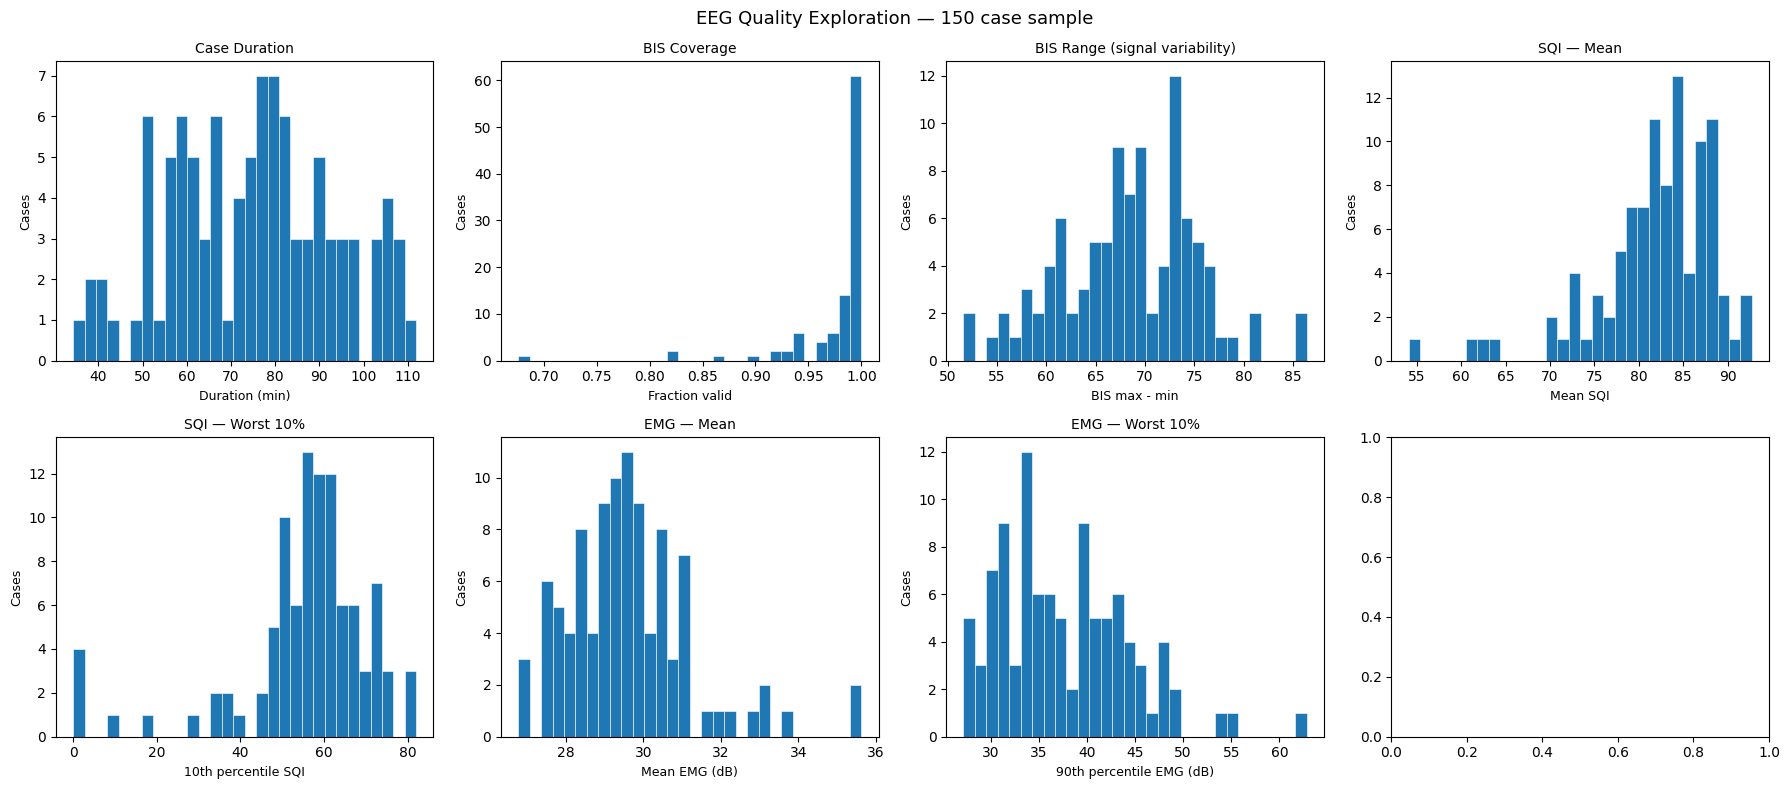

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('EEG Quality Exploration — 150 case sample', fontsize=13)

plots = [
    ('duration_min',  'Duration (min)',         'Case Duration'),
    ('bis_coverage',  'Fraction valid',          'BIS Coverage'),
    ('bis_range',     'BIS max - min',           'BIS Range (signal variability)'),
    ('sqi_mean',      'Mean SQI',                'SQI — Mean'),
    ('sqi_p10',       '10th percentile SQI',     'SQI — Worst 10%'),
    ('emg_mean',      'Mean EMG (dB)',            'EMG — Mean'),
    ('emg_p90',       '90th percentile EMG (dB)','EMG — Worst 10%'),
]

for ax, (col, xlabel, title) in zip(axes.flat, plots):
    ax.hist(df[col].dropna(), bins=30, edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Cases', fontsize=9)

plt.tight_layout()
plt.savefig('eeg_quality_exploration.png', dpi=150)
plt.show()

data